# Market Seams on the WSCC 9-Bus Network

This notebook builds small, hand-tunable examples on the WSCC / IEEE 9-bus test
system to make three structural results of multi-engine markets concrete:

| Section | What you see |
|---|---|
| **1. Shared network & shift factors** | The network $\mathcal N,\mathcal M$ and the shift-factor matrix $SF_{n,m}$ |
| **2. One engine (unified clearing)** | DC power flow, nodal LMPs $\lambda_n$, congestion on constrained paths |
| **3. Two engines — dispatch interference** | Each engine within its own limits, **combined flow overloads** |
| **4. Two engines — price-taking export** | A's export is a **fixed, price-insensitive** input to B; the **seam dual gap** $\Delta\lambda_n$ |
| **5. Sandbox** | Knobs for footprints, costs, ratings, interchange |

All computation lives in [`seams_engine.py`](seams_engine.py): a transparent
PTDF DC-OPF with objects $SF_{n,m}$, $\lambda^M_n$, $\mu^M_m$, $F^M_m$, and the
superposition $F^{\text{phys}}=\sum_M F^M$. Each *engine* optimises only its own
resources and loads, enforces limits only on its own activated constraints, and
computes flow only against its own injections — the cross-engine pieces enter as
exogenous schedules.

> **How to use:** every section starts with an `# -- EDIT --` config cell. Change the
> numbers, re-run the section, watch the prices and flows move.

## 0. Setup

In [ ]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

from ieee9_network import build_ieee9_network
import seams_engine, nodal_plot
importlib.reload(seams_engine); importlib.reload(nodal_plot)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

# Clean tables on PDF export: give DataFrames/Series a booktabs LaTeX rendering.
# Jupyter and Colab still show the normal HTML tables; `nbconvert --to pdf` picks
# up this text/latex representation, so tables come out as real ruled tables
# (wide ones scaled to the text width) instead of wrapped monospace.
def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:   # wide -> scale to text width so nothing runs off the page
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

### Master fleet & load tables

The 9-bus system has three generators — the **cheapest at bus 3 (\$20)**, a
mid-merit unit at bus 2 (\$35), and a **dear unit at bus 1 (\$50)** — and three
loads. These are the physical primitives; the *market* partition (which bus
belongs to which engine) is chosen later and independently.

```
        (1)gen $50            (3)gen $20
          |                     |
         [4]---[5]load--------[6]---[7]load
          |                     |
         [9]load---[8]---------/
                    |
                  (2)gen $35
```
Lines (rating MW): `0:1-4(250) 1:4-5(250) 2:5-6(150) 3:3-6(300) 4:6-7(150) 5:7-8(250) 6:8-2(250) 7:8-9(250) 8:9-4(250)`

In [3]:
# Physical primitives -- the resource stack and loads on the shared network
GEN_FLEET = {
    'gen_slack_0': {'bus': '1', 'cost': 50.0, 'p_nom': 250.0},   # dear unit
    'gen_0':       {'bus': '2', 'cost': 35.0, 'p_nom': 300.0},   # mid-merit
    'gen_1':       {'bus': '3', 'cost': 20.0, 'p_nom': 170.0},   # cheapest unit
}
LOADS = {'5': 90.0, '7': 100.0, '9': 125.0}

# Circlize sector order: clockwise from 12 o'clock, following the network ring
# so the chord diagram reads in the same spatial order as the topology diagram.
RING_ORDER = ['3', '6', '7', '8', '2', '9', '4', '1', '5']

# Orientation, applied to ALL node + circlize plots so they read alike:
#  - node diagram rotated 180deg  -> bus 3 at the bottom, bus 2 NW, bus 9 at top;
#  - circlize centred on bus 9    -> bus 9 across 12 o'clock, bus 3 near the bottom.
ROTATION_DEG = 180
CENTER_BUS = '9'
COORDS = nodal_plot.rotate_coords(nodal_plot.IEEE9_COORDS, ROTATION_DEG)

def build_network(line_ratings=None):
    # Build the 9-bus PyPSA network, applying any line-rating overrides.
    n = build_ieee9_network(periods=1)
    for ln, mw in (line_ratings or {}).items():
        n.lines.loc[ln, 's_nom'] = float(mw)
    return n

def make_engine(name, buses, activated='all'):
    # Assign every fleet gen and load whose bus is in `buses` to this engine.
    buses = {str(b) for b in buses}
    gens = {g: dict(s) for g, s in GEN_FLEET.items() if str(s['bus']) in buses}
    loads = {b: mw for b, mw in LOADS.items() if b in buses}
    return MarketEngine(name=name, gens=gens, loads=loads, activated_lines=activated)

print('fleet:', {g: (s['bus'], s['cost'], s['p_nom']) for g, s in GEN_FLEET.items()})
print('loads:', LOADS)
print('ring order:', RING_ORDER, '| rotation', ROTATION_DEG, 'deg | centre bus', CENTER_BUS)

fleet:

{'gen_slack_0': ('1', 50.0, 250.0), 'gen_0': ('2', 35.0, 300.0), 'gen_1': ('3', 20.0, 170.0)}

loads:

{'5': 90.0, '7': 100.0, '9': 125.0}

ring order:

['3', '6', '7', '8', '2', '9', '4', '1', '5']

| rotation

180

deg | centre bus

9

## 1. Shared network & shift factors

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

The shift-factor (PTDF) matrix is a primitive of the **physics**, shared by every
engine. Everything downstream — each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ — is built from this one matrix.

In [4]:
pt = compute_ptdf(build_network(), slack_bus='1')
SF = pd.DataFrame(pt.ptdf,
                  index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)],
                  columns=[f'bus {b}' for b in pt.buses]).round(3)
print('Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)')
SF

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)

,bus 1,bus 2,bus 3,bus 4,bus 5,bus 6,bus 7,bus 8,bus 9
line_0 (1-4),0.0,-1.000,-1.000,-1.0,-1.000,-1.000,-1.000,-1.000,-1.000
line_1 (4-5),0.0,-0.361,-0.615,-0.0,-0.865,-0.615,-0.467,-0.361,-0.125
line_2 (5-6),0.0,-0.361,-0.615,-0.0,0.135,-0.615,-0.467,-0.361,-0.125
line_3 (3-6),0.0,0.000,1.000,-0.0,0.000,0.000,-0.000,0.000,0.000
line_4 (6-7),0.0,-0.361,0.385,0.0,0.135,0.385,-0.467,-0.361,-0.125
line_5 (7-8),0.0,-0.361,0.385,-0.0,0.135,0.385,0.533,-0.361,-0.125
line_6 (8-2),0.0,-1.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000
line_7 (8-9),0.0,0.639,0.385,0.0,0.135,0.385,0.533,0.639,-0.125
line_8 (9-4),0.0,0.639,0.385,0.0,0.135,0.385,0.533,0.639,0.875


### Line admittance map

The WSCC 9-bus assigns a distinct reactance $x_m$ to every line. For DC flow the
power a line carries per unit of angle difference across it is its **susceptance**
$b_m = 1/x_m$. The cell below draws each line with a width
proportional to $b_m$ (wider = lower $x$ = more admittance), giving a physical
picture of *where power prefers to flow* before any dispatch is chosen. Width is an
**orthogonal channel** to the congestion colour used later: width = susceptance,
red = binding.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


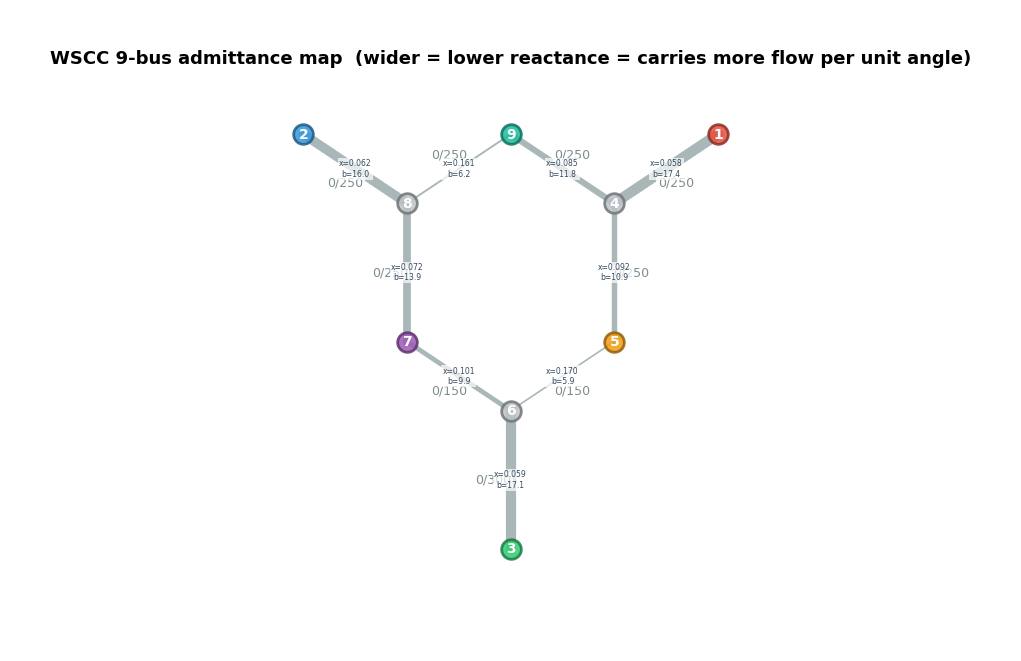

,x (reactance),b = 1/x,draw width
line_0 (1-4),0.0576,17.36,7.50
line_3 (3-6),0.0586,17.06,7.34
line_6 (8-2),0.0625,16.00,6.75
line_5 (7-8),0.0720,13.89,5.59
line_8 (9-4),0.0850,11.76,4.43
line_1 (4-5),0.0920,10.87,3.94
line_4 (6-7),0.1008,9.92,3.42
line_7 (8-9),0.1610,6.21,1.38
line_2 (5-6),0.1700,5.88,1.20


In [5]:
pt = compute_ptdf(build_network(), slack_bus='1')
widths = susceptance_widths(pt, wmin=1.2, wmax=7.5)   # {line: linewidth} from b = 1/x

# Colour the nodes with the SAME per-bus palette used throughout the notebook:
# gen/load buses take their palette colour, pure transit buses stay grey. The
# membership comes from the fleet (not the dispatch), so these node colours match
# the dispatched figures exactly -- this is purely a reactance map, no flows.
sup = {}
for _g, _s in GEN_FLEET.items():
    sup.setdefault(_s['bus'], []).append(_s)
node_colors = assign_bus_colors(pt.buses, sup, LOADS)

# Pure admittance map: no dispatch annotations, no flows -- width encodes
# susceptance only, nodes carry the standard palette colour.
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=node_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines},   # 0 flow -> no arrows, grey lines
    line_widths=widths,
    title='WSCC 9-bus admittance map  (wider = lower reactance = carries more flow per unit angle)',
)
# annotate each line with its x and b
for l, (b0, b1) in zip(pt.lines, pt.line_buses):
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    b = pt.susceptance[pt.line_idx[l]]
    ax.text(xm, ym, f'x={1/b:.3f}\nb={b:.1f}', fontsize=5.5, ha='center', va='center',
            color='#34495E', bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.8), zorder=6)
plt.show()

pd.DataFrame({
    'x (reactance)': [round(1 / pt.susceptance[pt.line_idx[l]], 4) for l in pt.lines],
    'b = 1/x': [round(pt.susceptance[pt.line_idx[l]], 2) for l in pt.lines],
    'draw width': [round(widths[l], 2) for l in pt.lines],
}, index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)]).sort_values('b = 1/x', ascending=False)

## 2. One engine — the unified clearing

A single optimisation over **all** resources, loads, and constraints. This is the
benchmark the seams problem is measured against: one price per bus, every
transmission limit enforced against the true total flow.

**Edit below:** generator costs, load levels, and line ratings. Tightening a line
creates congestion and pulls the LMPs apart — *price separation on the constrained
path*.

### The dispatch each engine solves, its Lagrangian, and the bus prices

`solve_engine_dispatch` clears **one engine's** DC-OPF on the shared network: a
bid-based security-constrained economic dispatch (SCED) reduced to a **single
period with energy-cost bids only** (no unit commitment) and a **single
system-wide energy balance**. An engine $M$ brings its resources $\mathcal R^M$
(cost $c_i$, cap $\bar g_i$ at bus $\mathrm{bus}(i)$), its served load $d_n$, an
activated line set $\mathcal M^M_{\mathrm{act}}$, and any **exogenous** cross-seam
schedule $\mathrm{exo}_n$ (zero for a stand-alone clear).

**Objective — minimise the engine's own dispatch cost.**

$$\min_{0\le g_i\le \bar g_i}\ \ C^M=\sum_{i\in\mathcal R^M} c_i\,g_i. \qquad\qquad(1)$$

*In words.* Stack up the engine's own generators cheapest-first to cover its obligation
(no-load, start-up and shut-down terms drop out in this single-period, energy-only cut).

**Energy balance — its dual is the energy price $\lambda^M$.**

$$\sum_{i\in\mathcal R^M} g_i=\sum_n d_n-\sum_n \mathrm{exo}_n. \qquad\qquad(2)\quad[\lambda^M]$$

*In words.* The engine's generation serves its own load net of any scheduled interchange:
$\mathrm{exo}_n>0$ is power injected into the footprint (an import), $\mathrm{exo}_n<0$ a
withdrawal (an export). $\lambda^M$ is the single system-wide energy price (`res.energy_price`).

**Flow and activated limits — duals $\mu^M_m$.**

$$F^M_m=\sum_n SF_{n,m}\,p^{\mathrm{inj},M}_n,\qquad
  -\bar F_m\le F^M_m\le \bar F_m\ \ [\mu^M_m]\ \ (m\in\mathcal M^M_{\mathrm{act}}),\qquad
  p^{\mathrm{inj},M}_n=\!\!\!\sum_{i\in\mathcal R^M:\,\mathrm{bus}(i)=n}\!\!\!g_i-d_n+\mathrm{exo}_n. \qquad(3)$$

*In words.* The engine's flow on a line is the shift-factor-weighted sum of **its own** net
injections, held within the rating **only on the lines it activates**. A line outside
$\mathcal M^M_{\mathrm{act}}$ has its limit relaxed and stays silent (`activated_lines`).

**The Lagrangian.**

$$\mathcal L^M(g,\lambda^M,\mu^M,\underline\mu^M,\overline\mu^M)=\sum_i c_i\,g_i-\lambda^M\!\Big(\sum_i g_i-\sum_n d_n+\sum_n\mathrm{exo}_n\Big)-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!\mu^M_m\,F^M_m+\sum_i\overline\mu^M_i\,(g_i-\bar g_i)-\sum_i\underline\mu^M_i\,g_i. \qquad(4)$$

*In words.* Cost, minus the energy-balance multiplier times the imbalance, minus each activated
line's (signed) congestion multiplier times the flow on it, plus one multiplier per generator
capacity limit: $\overline\mu^M_i\ge 0$ on the upper limit $g_i\le\bar g_i$ and
$\underline\mu^M_i\ge 0$ on the lower limit $g_i\ge 0$. $\lambda^M$ and the $\mu^M_m$ are exactly
`res.energy_price` and `res.line_dual`.

**Complementary slackness.** Each capacity multiplier is non-zero only when its own limit binds:

$$\overline\mu^M_i\,(g_i-\bar g_i)=0,\qquad \underline\mu^M_i\,g_i=0,\qquad \overline\mu^M_i,\underline\mu^M_i\ge 0.$$

A fully-loaded unit ($g_i=\bar g_i$) may carry $\overline\mu^M_i>0$, an idle unit ($g_i=0$) may
carry $\underline\mu^M_i>0$, and a **marginal** unit ($0<g_i<\bar g_i$) has both equal to zero.

**Stationarity — where the price comes from.** At the optimum the Lagrangian is stationary in
each dispatch variable. For a generator $i$ at bus $n=\mathrm{bus}(i)$, using $\partial F^M_m/\partial g_i=SF_{n,m}$:

$$\frac{\partial \mathcal L^M}{\partial g_i}
  = c_i-\lambda^M-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^M_m\;+\;\overline\mu^M_i-\underline\mu^M_i\;=\;0 .$$

For a **marginal** unit the two bound multipliers vanish by complementary slackness, so the
$\overline\mu^M_i-\underline\mu^M_i$ term drops and we are left with
$c_i=\lambda^M+\sum_{m}SF_{n,m}\,\mu^M_m$.

**Nodal LMP — the price at every bus.**

$$\lambda^M_n=\lambda^M+\sum_{m\in\mathcal M^M_{\mathrm{act}}}SF_{n,m}\,\mu^M_m. \qquad\qquad(5)$$

*In words.* A bus's price is the system energy price plus, for every binding activated line, that
line's shadow price scaled by the bus's shift factor onto it. With nothing binding, every bus
collapses to the one price $\lambda^M$. **Section 2 runs the unified counterfactual**: a single
engine over **all** buses with $\mathrm{exo}=0$ and every limit enforced — the single-price
benchmark the rest of the notebook builds on.

In [6]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0}   # squeeze line_4 (6-7) below its ~63 MW natural flow
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 0.0, 'gen_0': 176.1, 'gen_1': 138.9}

energy price :

27.74

$/MWh

binding lines:

{'line_4': -20.1}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,27.74,35.0,20.0,27.74,25.02,20.0,37.13,35.0,30.25


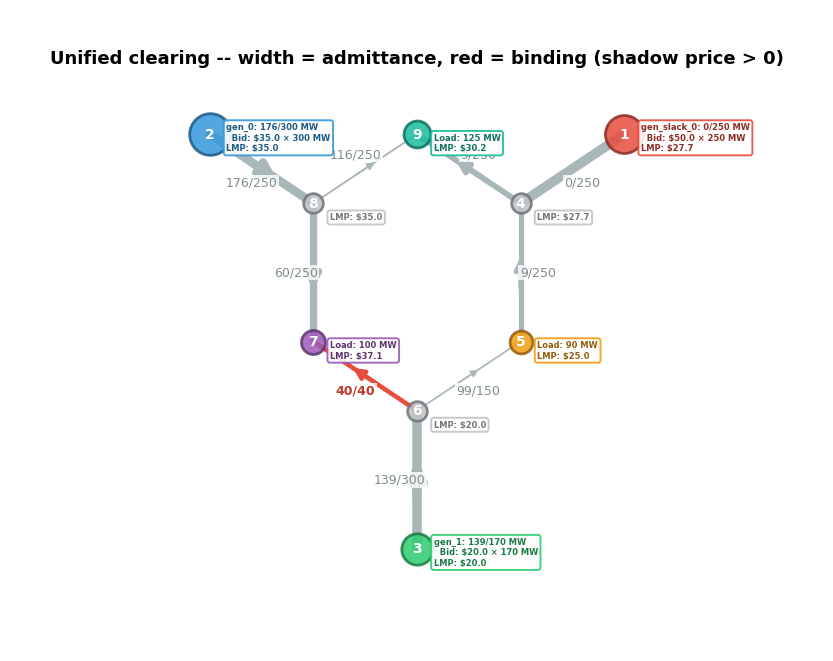

In [7]:
# Topology with DC power flow. Line WIDTH = susceptance (b=1/x); line COLOUR =
# congestion. A line is red only when its shadow price is non-zero (a genuine
# binding transmission limit) -- NOT merely when flow hits rating, which can
# happen because the generator behind a radial line is maxed out.
sup, dem = to_supply_demand(unified, res)
colors = assign_bus_colors(pt.buses, sup, dem)
flows = {l: res.flow_own[l] for l in pt.lines}
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=res.lmp, line_flows=flows,
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines, bus_coords=COORDS,
    title='Unified clearing -- width = admittance, red = binding (shadow price > 0)',
)
plt.show()

### Nodal merit-order + chord view, and the congestion shadow price

The circlize / chord view, built here from the unified DC-OPF. Each sector is a bus: the **left** half is the
merit-order staircase: **each bar's height is that unit's marginal cost** (its bid) -- solid
where dispatched, faded where it is available capacity. A **dashed line is drawn across each
bus at its cleared LMP**; the gap between a dispatched bar's top and that line is the unit's
**inframarginal rent** (LMP - marginal cost), while a bar rising *above* the line is out of
merit at this price and stays undispatched. The **right** half is the demand bar drawn at
**LMP height**, and the
**chords** are PTDF-traced generator→load deliveries. Below the figure we print the
congestion shadow price $\mu_m$ on each binding line — the dual of the binding-line
limit, and the exact quantity that splits the LMPs through $\sum_m SF_{n,m}\,\mu_m$.

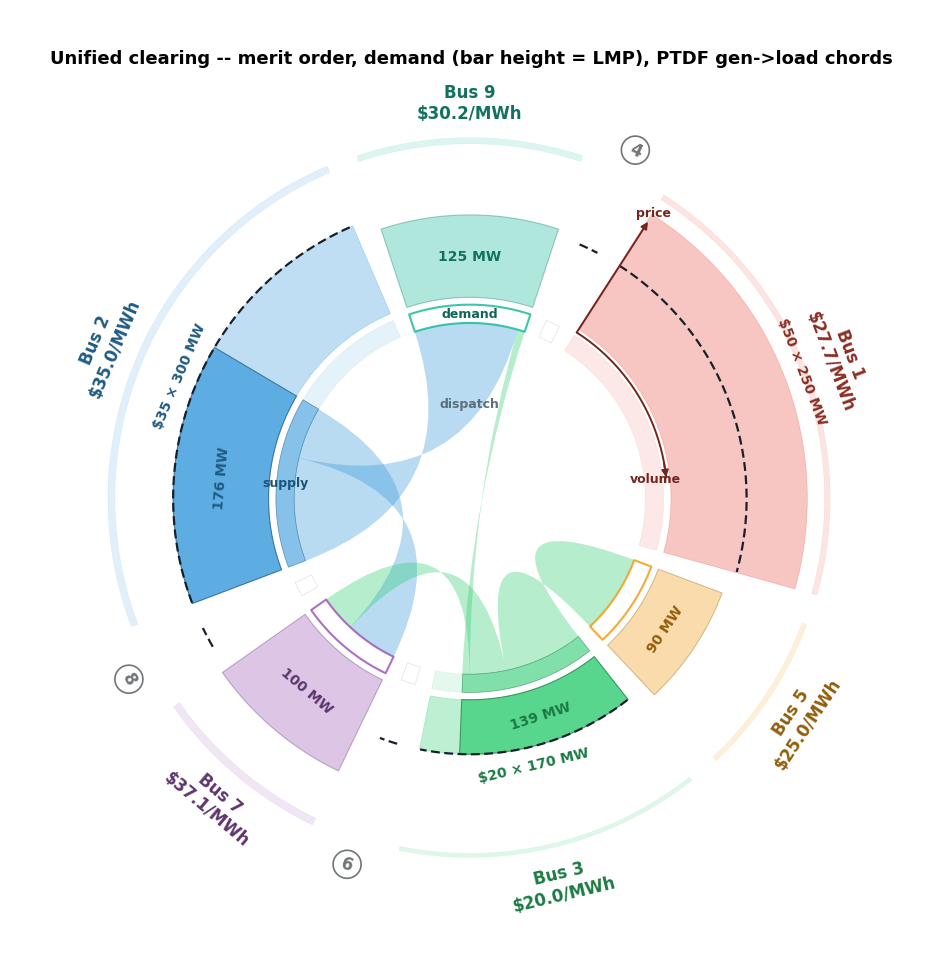

Binding transmission constraints -- congestion shadow price |mu_m|:

  line_4 (6-7): |mu| = $20.10/MWh   (flow +40 MW at the 40 MW limit)


Settlement by node  (payments to generation vs payments by load):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,27.74,0.0,0.0,0.0,0.0
2,35.0,176.1,6162.4,0.0,0.0
3,20.0,138.9,2778.6,0.0,0.0
4,27.74,0.0,0.0,0.0,0.0
5,25.02,0.0,0.0,90.0,2251.8
6,20.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
8,35.0,0.0,0.0,0.0,0.0
9,30.25,0.0,0.0,125.0,3780.8


Congestion rent  =  paid by load  -  paid to gen  =  9,745.2  -  8,941.0  =  $804.2/h

...

(equal by the LMP decomposition: the energy component nets to zero because total gen = total load,
 so only the congestion term survives, and it equals mu x flow on each binding line.)


Marginal value of line capacity  (shadow price x flow, per line):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,-0.0,250.0,False,0.0,0.0
line_1,4,5,-8.9,250.0,False,0.0,0.0
line_2,5,6,-98.9,150.0,False,0.0,0.0
line_3,3,6,138.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-176.1,250.0,False,0.0,0.0
line_7,8,9,116.1,250.0,False,0.0,0.0
line_8,9,4,-8.9,250.0,False,0.0,0.0


The |mu| column is the value of relaxing each line by 1 MW; only binding lines carry a positive value.
The rent column decomposes the congestion rent above by line and totals $804.1/h.


wrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  C:\Users\docke\Projects\ASSUME\assume\testbed

In [8]:
# Circlize / chord view of the unified clearing (reuses sup, dem, colors, res from above).
flow_list = nodal_plot.compute_ptdf_flows(net, sup, dem)   # PTDF-traced gen->load chords

fig = plot_nodal_circlize(
    sup, dem, pt.buses,
    flows=flow_list,
    clearing_price=res.energy_price,
    bus_lmps=res.lmp,
    bus_colors=colors,
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost (gap = inframarginal rent)
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    sector_order=RING_ORDER,   # clockwise from 12 o'clock, following the network ring
    center_bus=CENTER_BUS,     # bus 9 centred at 12 o'clock (matches the rotated node diagram)
    figsize=(8.5, 9.0),        # fills the width of an 8.5x11 page (extra height -> title headroom)
    label_fontsize=12,         # outer sector labels (Bus N / LMP)
    track_fontsize=10,         # in-track bid / dispatch / load-MW labels, >= 10 pt
    show_legend=False,         # per-bus gen/load/LMP already on the ring + in-track; legend was sub-10 pt and duplicative
    title='Unified clearing -- merit order, demand (bar height = LMP), PTDF gen->load chords',
)
plt.show()

# Shadow price of the binding line constraint(s): the congestion dual mu_m.
binding = {l: mu for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
if binding:
    print('Binding transmission constraints -- congestion shadow price |mu_m|:')
    for l, mu in sorted(binding.items(), key=lambda kv: -abs(kv[1])):
        i = pt.line_idx[l]; a, b = pt.line_buses[i]
        print(f'  {l} ({a}-{b}): |mu| = ${abs(mu):.2f}/MWh   '
              f'(flow {res.flow_own[l]:+.0f} MW at the {pt.s_nom[i]:.0f} MW limit)')
else:
    print('No binding line constraints -- every bus collapses to the single energy price.')

# â”€â”€ Settlement accounting: payments by node, subtotals, congestion rent â”€â”€â”€â”€â”€â”€
# Convention: "paid to gen" is cash IN to generators (LMP x dispatch); "paid by
# load" is cash OUT from loads (LMP x demand). The system operator collects the
# difference as congestion rent / merchandising surplus -- and that residual
# equals the shadow-price money  sum_m |mu_m| * F_m  (the price-difference rent).
settle = pd.DataFrame(
    [{'bus': b,
      'LMP ($/MWh)': round(res.lmp[b], 2),
      'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
      'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
      'load (MW)': round(unified.loads.get(b, 0.0), 1),
      'paid by load ($/h)': round(res.lmp[b] * unified.loads.get(b, 0.0), 1)}
     for b in pt.buses]
).set_index('bus')

gen_rev  = settle['paid to gen ($/h)'].sum()    # subtotal: total to generation
load_pay = settle['paid by load ($/h)'].sum()   # subtotal: total from load
settle.loc['SUBTOTAL'] = ['', settle['gen (MW)'].sum(), gen_rev,
                          settle['load (MW)'].sum(), load_pay]

print('\nSettlement by node  (payments to generation vs payments by load):')
display(settle)

cong_rent = load_pay - gen_rev
mu_money  = sum(abs(mu) * abs(res.flow_own[l]) for l, mu in binding.items())
print(f'Congestion rent  =  paid by load  -  paid to gen  '
      f'=  {load_pay:,.1f}  -  {gen_rev:,.1f}  =  ${cong_rent:,.1f}/h')
print(f'Shadow-price check:  sum_m |mu_m| * F_m over binding lines  =  ${mu_money:,.1f}/h')
print('(equal by the LMP decomposition: the energy component nets to zero because '
      'total gen = total load,\n so only the congestion term survives, and it equals mu x flow on each binding line.)')

# â”€â”€ Marginal value of line capacity: shadow price x flow, per line â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# |mu_m| is the $/MWh fall in system cost from +1 MW of rating on line m (zero
# unless the line binds) -- the marginal value of capacity. |mu_m| x flow is the
# congestion rent that line collects; the column sums to the total rent above.
lines_tbl = pd.DataFrame(
    [{'line': l,
      'from': pt.line_buses[pt.line_idx[l]][0],
      'to': pt.line_buses[pt.line_idx[l]][1],
      'flow (MW)': round(res.flow_own[l], 1),
      'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
      'binding': abs(res.line_dual[l]) > 1e-3,
      '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
      'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
     for l in pt.lines]
).set_index('line')
lines_tbl.loc['TOTAL'] = ['', '', '', '', '', '',
                          round(lines_tbl['rent |mu| x flow ($/h)'].sum(), 1)]

print('\nMarginal value of line capacity  (shadow price x flow, per line):')
display(lines_tbl)
print('The |mu| column is the value of relaxing each line by 1 MW; only binding '
      'lines carry a positive value.\nThe rent column decomposes the congestion '
      f'rent above by line and totals ${lines_tbl.loc["TOTAL", "rent |mu| x flow ($/h)"]:,.1f}/h.')

# â”€â”€ Export both tables to CSV (overwritten every run) for the Word write-up â”€â”€
settle.to_csv('seams_settlement_by_node.csv')
lines_tbl.to_csv('seams_line_capacity_value.csv')
print(f'\nwrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  {os.getcwd()}')

### Letter-size composite figure (for the write-up)

The network diagram and the circlize/chord diagram laid out **side by side**,
sized so the fonts stay clean at half-page width:

- node numbers sit in small chips **beside** each bubble (the coloured marker stays
  uncluttered); only the **LMP** is printed at each bus — the gen/bid/load detail
  lives in the chord panel, so nothing is duplicated;
- on each circlize sector the **bid** sits *outside / on top of* the gen bar and the
  **dispatched MW** sits *inside* it (mirroring the load bar, which prints its MW
  in-track); in-track labels are placed by bar height so they stay inside the bar;
- saved as a 300-dpi PNG and a vector PDF, overwritten each run.

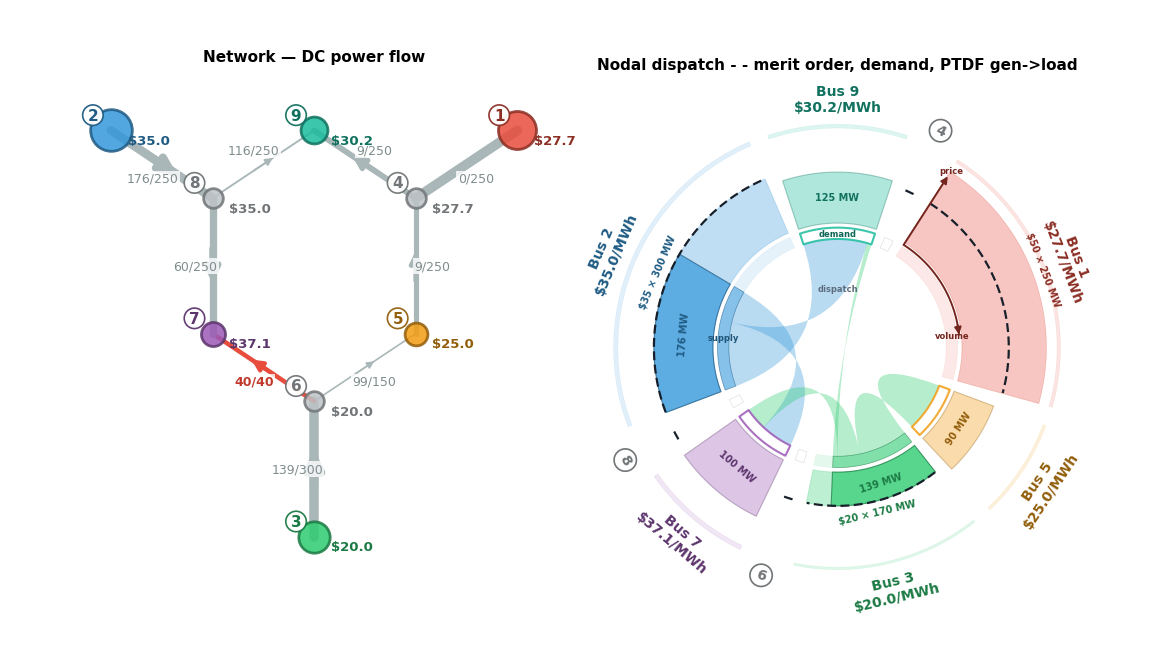

wrote seams_combined_figure.png (300 dpi) and seams_combined_figure.pdf to C:\Users\docke\Projects\ASSUME\assume\testbed

In [9]:
from nodal_plot import plot_combined_letter

binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, dem),
    clearing_price=res.energy_price,
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,   # rotated node diagram + bus 9 at 12 o'clock
)
fig.savefig('seams_combined_figure.png', dpi=300, bbox_inches='tight')
fig.savefig('seams_combined_figure.pdf', bbox_inches='tight')   # vector, for Word
plt.show()
print(f'wrote seams_combined_figure.png (300 dpi) and seams_combined_figure.pdf to {os.getcwd()}')

**Read it:** with `line_4` (6–7) squeezed to 40 MW, the binding internal limit
splits the LMPs — the bus-7 load behind the constraint prices up to ~\$37 while the
cheap bus-3 pocket (\$20) stays low. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$; set `LINE_RATINGS = {}` and re-run to collapse every bus
back to a single energy price.

## 3. Two engines — dispatch interference

Now **partition** the same network into two independent engines. Each one:

- optimises only its own generators against its own load (+ any scheduled interchange),
- enforces line limits only on its **own** computed flow component $F^M_m$,
- is blind to the other engine's contribution.

The wire, however, carries the **sum** $F^{\text{phys}}_m=\sum_M F^M_m$.
So a line can sit comfortably within each engine's limit yet be **physically
overloaded** — a limit on the *total* flow that no single engine enforces.

**Edit below:** which buses belong to engine A vs B, the A→B interchange, and the
ratings of the lines the combined flow rides on.

*Reading the maps below.* Lines are **coloured by the market that owns them** (A - WEM red, B - Markets+ blue); a **seam line** between the two markets stays **grey**, and a line that turns **bright red** is overloaded (its physical flow exceeds the rating), which overrides the market colour.

### The flow superposition behind the overload

Each engine clears the model above on its own footprint; the **wire carries the sum**.

**Each engine's own flow — and what it ignores.**

$$F^M_m=\sum_n SF_{n,m}\,p^{\mathrm{inj},M}_n. \qquad\qquad(6)$$

*In words.* Engine $M$'s computed flow sums shift factors against **only its own** injections.
The other engine's injections contribute **zero** to $F^M_m$ even though their shift factors are
non-zero — the algebraic root of the interference.

**The physical flow is the superposition of both.**

$$F^{\mathrm{phys}}_m=\sum_n SF_{n,m}\,p^{\mathrm{inj,phys}}_n=\sum_{M}F^M_m\;\big(+\,F^{\mathrm{non}}_m\big). \qquad\qquad(7)$$

*In words.* By linearity of DC power flow the actual flow that heats the wire is the sum of every
engine's component (plus any non-market residual). That is exactly the `F_phys` column —
identical to adding the `F[A]` and `F[B]` columns (`physical_flows`).

**What each engine enforces vs. what the wire enforces.**

$$\underbrace{\;|F^M_m|\le \bar F_m\ \ \forall M\;}_{\text{each engine — its own component}}
  \qquad\Longrightarrow\!\!\!\!\!\diagup\qquad
  \underbrace{\;\Big|\textstyle\sum_M F^M_m\Big|\le \bar F_m\;}_{\text{the wire — the total}} \qquad\qquad(8)$$

*In words.* Each engine keeps **its own** component within the rating, but nothing keeps **their
sum** within it — the left does **not** imply the right. When the two components share a sign the
physical flow can exceed the limit while every engine reports a feasible, within-limits dispatch:
the `overload` column. No market-to-market reconciliation is running here to bring the two clears
into agreement before the wire does.

In [10]:
# -- EDIT -- footprints, interchange, ratings -----------------------------
A_BUSES = ['1', '2', '4', '7', '8']     # engine A -- gen-rich (exporter)
B_BUSES = ['3', '5', '6', '9']          # engine B -- load-heavy (importer)
INTERCHANGE_MW = 150.0                   # scheduled A -> B transfer (contract path 4->5)
EXPORT_BUS, IMPORT_BUS = '4', '5'
SEAM_RATINGS = {'line_1': 110.0, 'line_8': 120.0}   # 4-5 and 9-4; 110 < combined |F| so 4-5 overloads
# -------------------------------------------------------------------------

net = build_network(SEAM_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')
A = make_engine('A - WEM',      A_BUSES)
B = make_engine('B - Markets+', B_BUSES)

# A serves its load + the export (pseudo-withdrawal); B receives the import (price-taking)
rA = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -INTERCHANGE_MW})
rB = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +INTERCHANGE_MW})

a_disp = ', '.join(f'{k}:{v:.0f}' for k, v in rA.dispatch.items())
b_disp = ', '.join(f'{k}:{v:.0f}' for k, v in rB.dispatch.items())
print(f'A dispatch [{a_disp}]   energy ${rA.energy_price:.0f}/MWh')
print(f'B dispatch [{b_disp}]   energy ${rB.energy_price:.0f}/MWh')

pf = physical_flows(pt, [rA, rB])
cols = ['from', 'to', 'F[A - WEM]', 'F[B - Markets+]', 'F_phys', 'rating', 'loading_%', 'overload']
print()
print("Line flows -- each engine's own component vs the physical total:")
pf[cols]

# -- Market line colours: a line internal to one market takes that market's
#    colour; a seam line (endpoints in different markets) stays grey. Used by
#    the superposition map and the side-by-side engine panels below.
MARKET_COLORS = {A.name: '#C0392B', B.name: '#2471A3'}   # A - WEM red, B - Markets+ blue
def market_of(b):
    return A.name if b in A_BUSES else (B.name if b in B_BUSES else None)
def market_line_colors(pt):
    out = {}
    for l in pt.lines:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        m0, m1 = market_of(b0), market_of(b1)
        out[l] = MARKET_COLORS[m0] if (m0 is not None and m0 == m1) else '#AAB7B8'
    return out


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


A dispatch [gen_slack_0:0, gen_0:250]   energy $35/MWh

B dispatch [gen_1:65]   energy $20/MWh

Line flows -- each engine's own component vs the physical total:

In [11]:
ovl = pf[pf.overload]
if len(ovl):
    for ln, row in ovl.iterrows():
        a, b = row['F[A - WEM]'], row['F[B - Markets+]']
        frm, to, rate, load = row['from'], row['to'], row['rating'], row['loading_%']
        print(f'[!] {ln} ({frm}-{to}): physical |{row.F_phys:.0f}| > {rate:.0f} MW rating ({load:.0f}%)')
        print(f'    A sees only {a:+.0f} MW, B sees only {b:+.0f} MW -- both within {rate:.0f}, '
              f'neither enforces the real limit.')
else:
    print('No overload at these settings -- raise INTERCHANGE_MW or tighten SEAM_RATINGS.')

[!] line_1 (4-5): physical |-120| > 110 MW rating (109%)

    A sees only -44 MW, B sees only -76 MW -- both within 110, neither enforces the real limit.

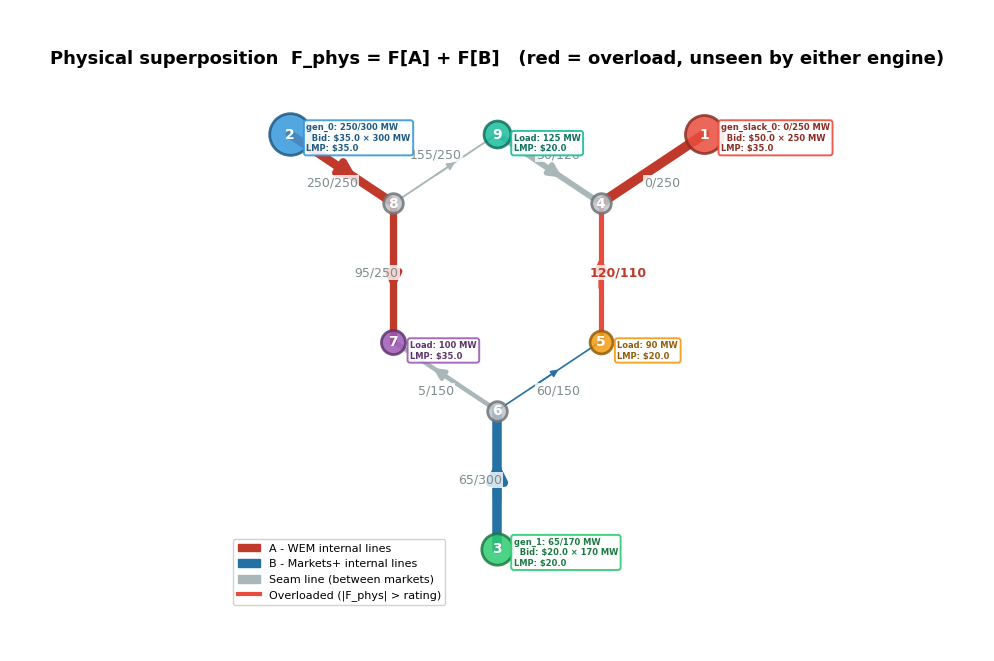

In [12]:
# Visual: physical superposition. Both engines' gens/loads on one map,
# line_flows = the PHYSICAL total. Width = susceptance; red = genuinely
# overloaded (|F_phys| > rating), not merely at rating because a gen is maxed.
sup, dem = {}, {}
for eng, r in [(A, rA), (B, rB)]:
    s, d = to_supply_demand(eng, r); sup.update(s); dem.update(d)
colors = assign_bus_colors(pt.buses, sup, dem)
# host LMP for annotation (host = engine that owns the bus)
host_lmp = {}
for r, eng in [(rA, A), (rB, B)]:
    for b in eng.buses: host_lmp[b] = r.lmp[b]
phys = {l: pf.loc[l, 'F_phys'] for l in pt.lines}
overloaded = set(pf[pf.overload].index)
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=host_lmp, line_flows=phys,
    line_widths=susceptance_widths(pt), line_colors=market_line_colors(pt),
    constrained_lines=overloaded, bus_coords=COORDS,
    title='Physical superposition  F_phys = F[A] + F[B]   (red = overload, unseen by either engine)',
)
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=f'{m} internal lines') for m in MARKET_COLORS]
          + [mpatches.Patch(color='#AAB7B8', label='Seam line (between markets)'),
             Line2D([0], [0], color='#E74C3C', lw=3, label='Overloaded (|F_phys| > rating)')],
          loc='lower left', fontsize=8, framealpha=0.9)
plt.show()

**The point.** Engine A's LP and engine B's LP both returned *feasible,
within-limits* solutions. Yet `line_1` (4-5) carries ~120 MW on a 110 MW wire because
each engine counted only its own injections (eq. 6) and treated the other's flow
as zero. This is the algebraic root of the interference: $|F^M_m|\le\bar F_m$ for each $M$ does
**not** imply $|\sum_M F^M_m|\le\bar F_m$. No M2M / ADMM exchange is running here,
so nothing reconciles the two dispatches before the wire does.

## 4. Two engines — the price-taking export & the seam dual gap

Same partition, but now look at the **trading layer**. From A's optimisation the
interchange is an *export decision*; from B's optimisation it is a **fixed,
price-insensitive injection** — a price taker that does not respond to B's LMP
(a cross-engine schedule fixed in advance and frozen during the clear).

Two consequences:

1. **The import does not respond to B's price.** Re-bid B's own generator and B's
   LMP moves, but the 150 MW keeps flowing in regardless.
2. **Seam dual gap** $\Delta\lambda_n=\lambda^B_n-\lambda^A_n\neq0$ at every bus:
   the two engines value the *same* physical megawatt differently
   because each optimises over a different feasible set.

### The price-taking interchange and the seam dual gap

**The interchange is a decision for A but a frozen injection for B.**

$$p^{\mathrm{inj},A}_{n}\ \text{includes}\ -E\ \text{at A's seam bus},\qquad
  p^{\mathrm{inj},B}_{n}\ \text{includes}\ +E\ \text{at B's seam bus},\qquad
  \mathrm{exo}\ \text{fixed before the clear}. \qquad(9)$$

*In words.* From A the export $E$ is a withdrawal it optimises; to B the **same** $E$ is a fixed,
price-insensitive injection (`exo`). B's own generation backs down one-for-one as $E$ rises, and the
import never re-prices against B's LMP — a price taker.

**Each engine prices the same bus through its own dispatch** (the nodal-LMP rule (5) of Section 2):

$$\lambda^A_n=\lambda^A+\!\!\sum_{m\in\mathcal M^A_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^A_m,
  \qquad\qquad
  \lambda^B_n=\lambda^B+\!\!\sum_{m\in\mathcal M^B_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^B_m. \qquad(10)$$

**Seam dual gap.**

$$\Delta\lambda^{A,B}_n:=\lambda^B_n-\lambda^A_n\ \neq\ 0. \qquad\qquad(11)$$

*In words.* The same physical megawatt carries two prices — one per engine — and their difference is
generically non-zero **even though the network is shared**. Three things differ between the engines:
the marginal unit (disjoint resource stacks $\mathcal R^A,\mathcal R^B$), the set of lines that bind
($\mathcal M^A_{\mathrm{act}}$ vs $\mathcal M^B_{\mathrm{act}}$), and the load each serves. This is the
`seam_dual_gap` column. With three engines each bus would carry three prices and three pairwise gaps;
a megawatt sold by A and bought by B settles on both sides of this gap — the trading friction.

In [13]:
# -- EDIT -- re-bid generators inside each engine, watch the import stay fixed --
A_COSTS = {}                 # e.g. {'gen_0': 55.0}  raise A's $35 bus-2 unit
B_COSTS = {}                 # e.g. {'gen_1': 15.0}  cheapen B's $20 bus-3 unit
# -------------------------------------------------------------------------
for g, c in A_COSTS.items(): A.gens[g]['cost'] = c
for g, c in B_COSTS.items(): B.gens[g]['cost'] = c

rows = []
for E in [50.0, 100.0, 150.0]:   # B needs >=45 MW import (215 MW load vs its 170 MW unit)
    rA = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -E})
    rB = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +E})
    rows.append({'import E (MW)': E,
                 'B own gen (MW)': round(sum(rB.dispatch.values()), 1),
                 'B served load (MW)': round(sum(B.loads.values()), 1),
                 'A energy $': round(rA.energy_price, 1),
                 'B energy $': round(rB.energy_price, 1),
                 'import price-taking?': 'yes -- fixed at E'})
print('B treats the import as exogenous: its own generation backs down 1-for-1 as E rises,')
print('the import never re-prices, and B energy price is set by B own marginal unit.')
print()
pd.DataFrame(rows)

B treats the import as exogenous: its own generation backs down 1-for-1 as E rises,

the import never re-prices, and B energy price is set by B own marginal unit.

,import E (MW),B own gen (MW),B served load (MW),A energy $,B energy $,import price-taking?
0,50.0,165.0,215.0,35.0,20.0,yes -- fixed at E
1,100.0,115.0,215.0,35.0,20.0,yes -- fixed at E
2,150.0,65.0,215.0,35.0,20.0,yes -- fixed at E


In [14]:
# Seam dual gap at every bus: three engines would give
# three LMPs per bus; with two engines there is one gap per bus.
rA = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -INTERCHANGE_MW})
rB = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +INTERCHANGE_MW})
gap = seam_dual_gap([rA, rB], pt.buses)
print('Each bus carries a host price and a counterparty price; the last column is the cross-engine basis.')
gap

Each bus carries a host price and a counterparty price; the last column is the cross-engine basis.

,λ[A - WEM],λ[B - Markets+],Δλ[A - WEM→B - Markets+]
bus,,,
1,35.0,20.0,-15.0
2,35.0,20.0,-15.0
3,35.0,20.0,-15.0
4,35.0,20.0,-15.0
5,35.0,20.0,-15.0
6,35.0,20.0,-15.0
7,35.0,20.0,-15.0
8,35.0,20.0,-15.0
9,35.0,20.0,-15.0


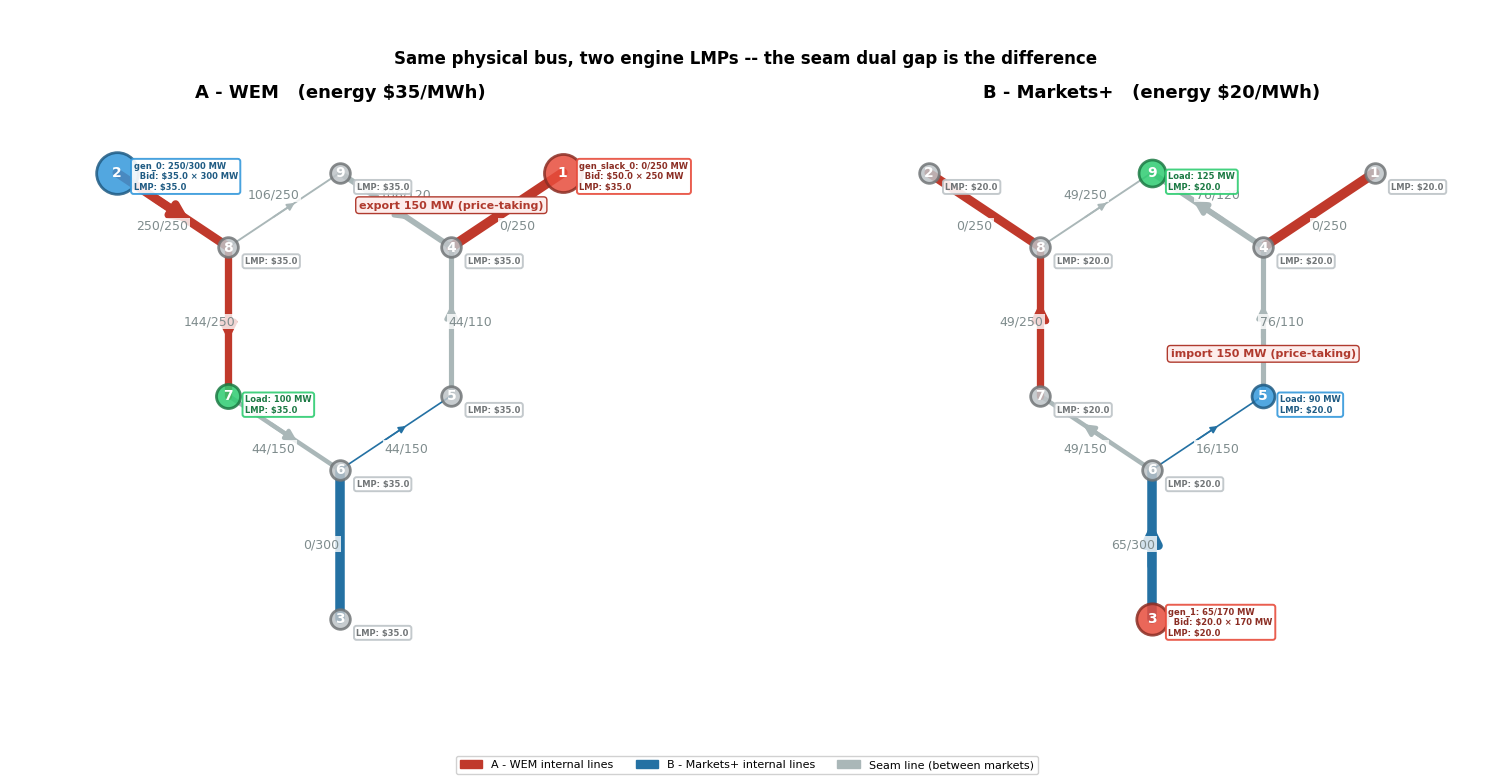

In [15]:
# The two engines side by side: same network, two different LMP fields.
# Width = susceptance (identical on both, it is the shared physics);
# red = that engine's own binding lines (shadow price > 0).
wdt = susceptance_widths(pt)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, eng, r in [(axes[0], A, rA), (axes[1], B, rB)]:
    s, d = to_supply_demand(eng, r)
    exo_note = {EXPORT_BUS: -INTERCHANGE_MW} if eng is A else {IMPORT_BUS: +INTERCHANGE_MW}
    cols = assign_bus_colors(pt.buses, s, d)
    bind = {l for l, mu in r.line_dual.items() if abs(mu) > 1e-3}
    plot_network_topology(
        net, s, d, bus_colors=cols, bus_lmps=r.lmp,
        line_flows={l: r.flow_own[l] for l in pt.lines}, line_widths=wdt,
        line_colors=market_line_colors(pt),
        constrained_lines=bind, bus_coords=COORDS, ax=ax,
        title=f'{eng.name}   (energy ${r.energy_price:.0f}/MWh)',
    )
    b = list(exo_note)[0]; mw = exo_note[b]
    label = ('export' if mw < 0 else 'import') + f' {abs(mw):.0f} MW (price-taking)'
    ax.annotate(label, COORDS[b], fontsize=8, fontweight='bold',
                color='#B03A2E', xytext=(0, 28), textcoords='offset points', ha='center',
                bbox=dict(boxstyle='round', fc='#FDEDEC', ec='#B03A2E'))
import matplotlib.patches as mpatches
fig.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=f'{m} internal lines') for m in MARKET_COLORS]
           + [mpatches.Patch(color='#AAB7B8', label='Seam line (between markets)')],
           loc='lower center', ncol=3, fontsize=8, framealpha=0.9)
plt.suptitle('Same physical bus, two engine LMPs -- the seam dual gap is the difference',
             fontweight='bold')
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

**Settlement friction.** A megawatt sold by A and bought by B settles
at A's interface price on one side and B's on the other; with $\Delta\lambda_n\neq0$
the two need not net to the transaction's physical value. The notebook shows the
two LMP fields. A *further* gap arises at the interface itself, where a
generator-weighted aggregation (CAISO's GAP-Tie) and a load-weighted average
(SPP's) summarise the same bus prices differently — layering on top of this
bus-level gap even when the underlying $\lambda$'s agree.

## 5. Sandbox

One cell, every knob. Reassign buses to engines, change which constraints each
engine *activates* (`activated_lines` = the discretionary set $\mathcal M^M_{\text{act}}$),
move the interchange, re-bid units. Re-run to see prices and the overload move.

In [16]:
# -- EDIT -- free-form two-engine experiment ------------------------------
RATINGS        = {'line_1': 120.0, 'line_8': 120.0}
A_BUSES        = ['1', '2', '4', '7', '8']
B_BUSES        = ['3', '5', '6', '9']
A_ACTIVATED    = 'all'        # or a list e.g. ['line_1','line_0'] -> A ignores the rest
B_ACTIVATED    = 'all'
COSTS          = {}           # {'gen_1': 30.0}
LOADS_OVERRIDE = {}           # {'9': 160.0}
E_MW           = 150.0
TIE            = ('4', '5')   # (export_bus in A, import_bus in B)
# -------------------------------------------------------------------------
net = build_network(RATINGS); pt = compute_ptdf(net, slack_bus='1')
for b, v in LOADS_OVERRIDE.items(): LOADS[b] = v
A = make_engine('A', A_BUSES, activated=A_ACTIVATED)
B = make_engine('B', B_BUSES, activated=B_ACTIVATED)
for eng in (A, B):
    for g, c in COSTS.items():
        if g in eng.gens: eng.gens[g]['cost'] = c
rA = solve_engine_dispatch(pt, A, exo={TIE[0]: -E_MW})
rB = solve_engine_dispatch(pt, B, exo={TIE[1]: +E_MW})

print('A energy', round(rA.energy_price, 1), '| B energy', round(rB.energy_price, 1))
pf = physical_flows(pt, [rA, rB])
print('overloads (invisible to both engines):', pf[pf.overload].index.tolist() or 'none')
display(seam_dual_gap([rA, rB], pt.buses))
display(pf[['from', 'to', 'F[A]', 'F[B]', 'F_phys', 'rating', 'loading_%', 'overload']])

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


A energy

35.0

| B energy

20.0

overloads (invisible to both engines):

none

,λ[A],λ[B],Δλ[A→B]
bus,,,
1,35.0,20.0,-15.0
2,35.0,20.0,-15.0
3,35.0,20.0,-15.0
4,35.0,20.0,-15.0
5,35.0,20.0,-15.0
6,35.0,20.0,-15.0
7,35.0,20.0,-15.0
8,35.0,20.0,-15.0
9,35.0,20.0,-15.0


,from,to,F[A],F[B],F_phys,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,-0.0,-0.0,-0.0,250.0,0.0,False
line_1,4,5,-43.6,-76.3,-119.9,120.0,100.0,False
line_2,5,6,-43.6,-16.3,-59.9,150.0,40.0,False
line_3,3,6,0.0,65.0,65.0,300.0,22.0,False
line_4,6,7,-43.6,48.7,5.1,150.0,3.0,False
line_5,7,8,-143.6,48.7,-94.9,250.0,38.0,False
line_6,8,2,-250.0,0.0,-250.0,250.0,100.0,False
line_7,8,9,106.4,48.7,155.1,250.0,62.0,False
line_8,9,4,106.4,-76.3,30.1,120.0,25.0,False


---
*Computation: [`seams_engine.py`](seams_engine.py) (PTDF DC-OPF, dual-derived LMPs).
Network: [`ieee9_network.py`](ieee9_network.py). Plots: [`nodal_plot.py`](nodal_plot.py).
Validated against an independent Egret SCED solution.*